# 🛒 Superstore Sales Analysis
**Business Story:** Help a retail store understand which products and regions are making or losing money.

### What you'll do in this notebook:
1. Upload and explore the dataset
2. Run SQL queries to answer business questions
3. Build visualizations for a portfolio dashboard

> **Dataset:** Download from [Kaggle Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) and upload when prompted below.

---
## 📦 Step 1: Install & Import Libraries

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set a clean plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 📂 Step 2: Upload the Dataset

In [ ]:
from google.colab import files

print('👇 Click the button below to upload your Superstore CSV file')
uploaded = files.upload()

👇 Click the button below to upload your Superstore CSV file


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
# Load the uploaded file into a DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='latin1')

print(f'✅ Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 10194 rows and 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


---
## 🔍 Step 3: Quick Data Exploration

In [ ]:
# Check column names
print('📋 Columns:', df.columns.tolist())

📋 Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
# Check data types and missing values
print('📊 Data Info:')
df.info()

📊 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10

In [ ]:
# Check for missing values
print('❓ Missing Values:')
print(df.isnull().sum())

❓ Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [ ]:
# Basic statistics
print('📈 Basic Statistics:')
df[['Sales', 'Profit', 'Quantity', 'Discount']].describe().round(2)

📈 Basic Statistics:


,Sales,Profit,Quantity,Discount
count,10194.00,10194.00,10194.00,10194.00
mean,228.23,28.67,3.79,0.16
std,619.91,232.47,2.23,0.21
min,0.44,-6599.98,1.00,0.00
25%,17.22,1.76,2.00,0.00
50%,53.91,8.69,3.00,0.20
75%,209.50,29.30,5.00,0.20
max,22638.48,8399.98,14.00,0.80


---
## 🗄️ Step 4: Set Up SQL Database

In [ ]:
# Load DataFrame into an in-memory SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('orders', conn, index=False, if_exists='replace')

print('✅ SQL database ready! Table name: orders')

✅ SQL database ready! Table name: orders


---
## 🧮 Step 5: SQL Queries — Answer Business Questions

> 💡 **Tip:** This is how real data analyst work looks. Each query answers a business question a client or manager might ask.

In [ ]:
# ── Query 1: Total Sales by Region ──
q1 = """
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM orders
    GROUP BY Region
    ORDER BY Total_Sales DESC
"""
df_region = pd.read_sql(q1, conn)
print('📍 Sales & Profit by Region:')
df_region

📍 Sales & Profit by Region:


,Region,Total_Sales,Total_Profit
0,West,739813.61,110798.82
1,East,691828.17,94883.26
2,Central,503170.67,39865.31
3,South,391721.91,46749.43


In [ ]:
# ── Query 2: Top 10 Products by Profit ──
q2 = """
    SELECT `Product Name`,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM orders
    GROUP BY `Product Name`
    ORDER BY Total_Profit DESC
    LIMIT 10
"""
df_top_products = pd.read_sql(q2, conn)
print('🏆 Top 10 Most Profitable Products:')
df_top_products

🏆 Top 10 Most Profitable Products:


,Product Name,Total_Profit,Total_Sales
0,Canon imageCLASS 2200 Advanced Copier,25199.93,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04,27453.38
2,Hewlett Packard LaserJet 3310 Copier,6983.88,18839.69
3,Canon PC1060 Personal Laser Copier,4570.93,11619.83
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98,18374.90
5,Ativa V4110MDD Micro-Cut Shredder,3772.95,7699.89
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97,14299.89
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28,9367.29
8,Ibico EPK-21 Electric Binding System,3345.28,15875.92
9,Zebra ZM400 Thermal Label Printer,3343.54,6965.70


In [ ]:
# ── Query 3: Bottom 10 Products (Losing Money) ──
q3 = """
    SELECT `Product Name`,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM orders
    GROUP BY `Product Name`
    ORDER BY Total_Profit ASC
    LIMIT 10
"""
df_bottom_products = pd.read_sql(q3, conn)
print('⚠️ Bottom 10 Least Profitable Products:')
df_bottom_products

⚠️ Bottom 10 Least Profitable Products:


,Product Name,Total_Profit,Total_Sales
0,Cubify CubeX 3D Printer Double Head Print,-8879.97,11099.96
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.97,16829.90
2,Cubify CubeX 3D Printer Triple Head Print,-3839.99,7999.98
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.12,9917.64
4,Bush Advantage Collection Racetrack Conference...,-1934.40,9544.73
5,GBC DocuBind P400 Electric Binding System,-1878.17,17965.07
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.08,22638.48
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.18,16656.20
8,Balt Solid Wood Round Tables,-1201.06,6518.75
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.44,1706.25


In [ ]:
# ── Query 4: Monthly Revenue Trends ──
q4 = """
    SELECT SUBSTR(`Order Date`, 1, 7) AS Month,
           ROUND(SUM(Sales), 2) AS Monthly_Sales,
           ROUND(SUM(Profit), 2) AS Monthly_Profit
    FROM orders
    GROUP BY Month
    ORDER BY Month
"""
df_monthly = pd.read_sql(q4, conn)
print('📅 Monthly Revenue Trends (first 12 months):')
df_monthly.head(12)

📅 Monthly Revenue Trends (first 12 months):


,Month,Monthly_Sales,Monthly_Profit
0,1/1/202,1481.83,-181.41
1,1/10/20,1247.68,-295.29
2,1/11/20,159.38,28.16
3,1/12/20,1703.13,-1038.71
4,1/13/20,8795.40,1040.60
5,1/14/20,1523.34,219.57
6,1/15/20,2992.15,559.31
7,1/16/20,6632.47,2605.27
8,1/17/20,1410.97,-117.78
9,1/18/20,64.86,6.49


In [ ]:
# ── Query 5: Sales & Profit by Product Category ──
q5 = """
    SELECT Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           COUNT(DISTINCT `Order ID`) AS Total_Orders
    FROM orders
    GROUP BY Category
    ORDER BY Total_Sales DESC
"""
df_category = pd.read_sql(q5, conn)
print('🗂️ Sales by Product Category:')
df_category

🗂️ Sales by Product Category:


,Category,Total_Sales,Total_Profit,Total_Orders
0,Technology,839893.28,146543.38,1560
1,Furniture,754747.76,19730.00,1819
2,Office Supplies,731893.31,126023.44,3812


In [ ]:
# ── Query 6: Profit Margin by Sub-Category ──
q6 = """
    SELECT `Sub-Category`,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin_Pct
    FROM orders
    GROUP BY `Sub-Category`
    ORDER BY Profit_Margin_Pct DESC
"""
df_subcategory = pd.read_sql(q6, conn)
print('📊 Profit Margin by Sub-Category:')
df_subcategory

📊 Profit Margin by Sub-Category:


,Sub-Category,Total_Sales,Total_Profit,Profit_Margin_Pct
0,Labels,12695.04,5572.78,43.90
1,Paper,79540.54,34511.51,43.39
2,Envelopes,16528.36,6988.02,42.28
3,Copiers,150745.29,56093.94,37.21
4,Fasteners,8532.24,2428.64,28.46
5,Accessories,167380.32,41936.64,25.05
6,Art,27659.01,6653.20,24.05
7,Appliances,108213.18,18329.48,16.94
8,Binders,207354.88,31426.10,15.16
9,Furnishings,95598.13,13891.74,14.53


In [ ]:
# ── Query 7: Top 10 Customers by Revenue ──
q7 = """
    SELECT `Customer Name`,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           COUNT(DISTINCT `Order ID`) AS Total_Orders
    FROM orders
    GROUP BY `Customer Name`
    ORDER BY Total_Sales DESC
    LIMIT 10
"""
df_customers = pd.read_sql(q7, conn)
print('👤 Top 10 Customers by Revenue:')
df_customers

👤 Top 10 Customers by Revenue:


,Customer Name,Total_Sales,Total_Profit,Total_Orders
0,Sean Miller,25043.05,-1980.74,5
1,Tamara Chand,19052.22,8981.32,5
2,Raymond Buch,15117.34,6976.10,6
3,Tom Ashbrook,14595.62,4703.79,4
4,Adrian Barton,14473.57,5444.81,10
5,Ken Lonsdale,14175.23,806.86,12
6,Sanjit Chand,14142.33,5757.41,9
7,Hunter Lopez,12873.30,5622.43,6
8,Sanjit Engle,12209.44,2650.68,11
9,Christopher Conant,12129.07,2177.05,5


---
## 📊 Step 6: Build Visualizations (Your Portfolio Dashboard)

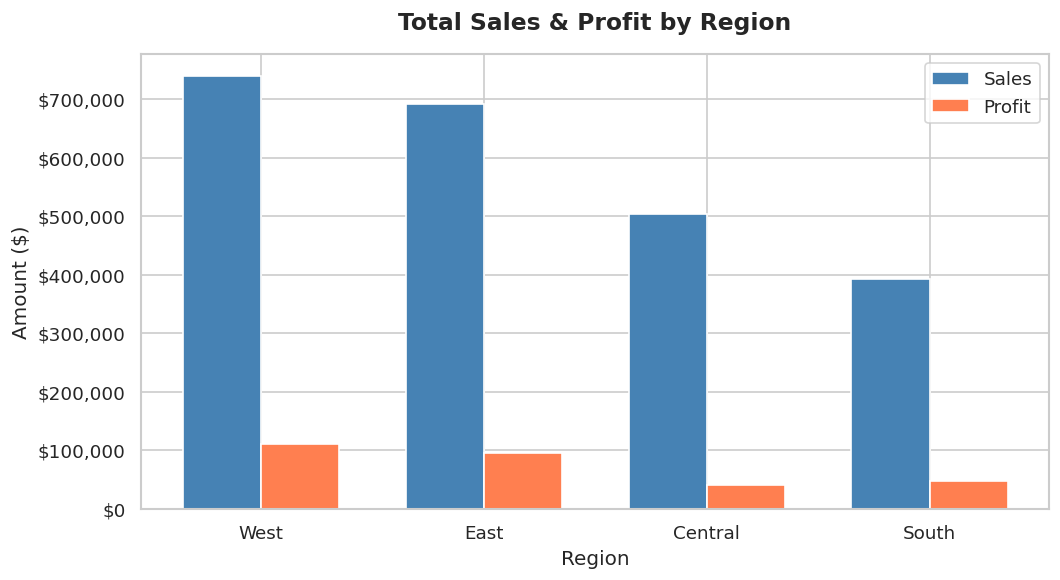

✅ Chart 1 saved!


In [ ]:
# ── Chart 1: Sales & Profit by Region ──
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(df_region))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_region['Total_Sales'], width, label='Sales', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], df_region['Total_Profit'], width, label='Profit', color='coral')

ax.set_title('Total Sales & Profit by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')
ax.set_xticks(list(x))
ax.set_xticklabels(df_region['Region'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('chart1_region.png', bbox_inches='tight')
plt.show()
print('✅ Chart 1 saved!')

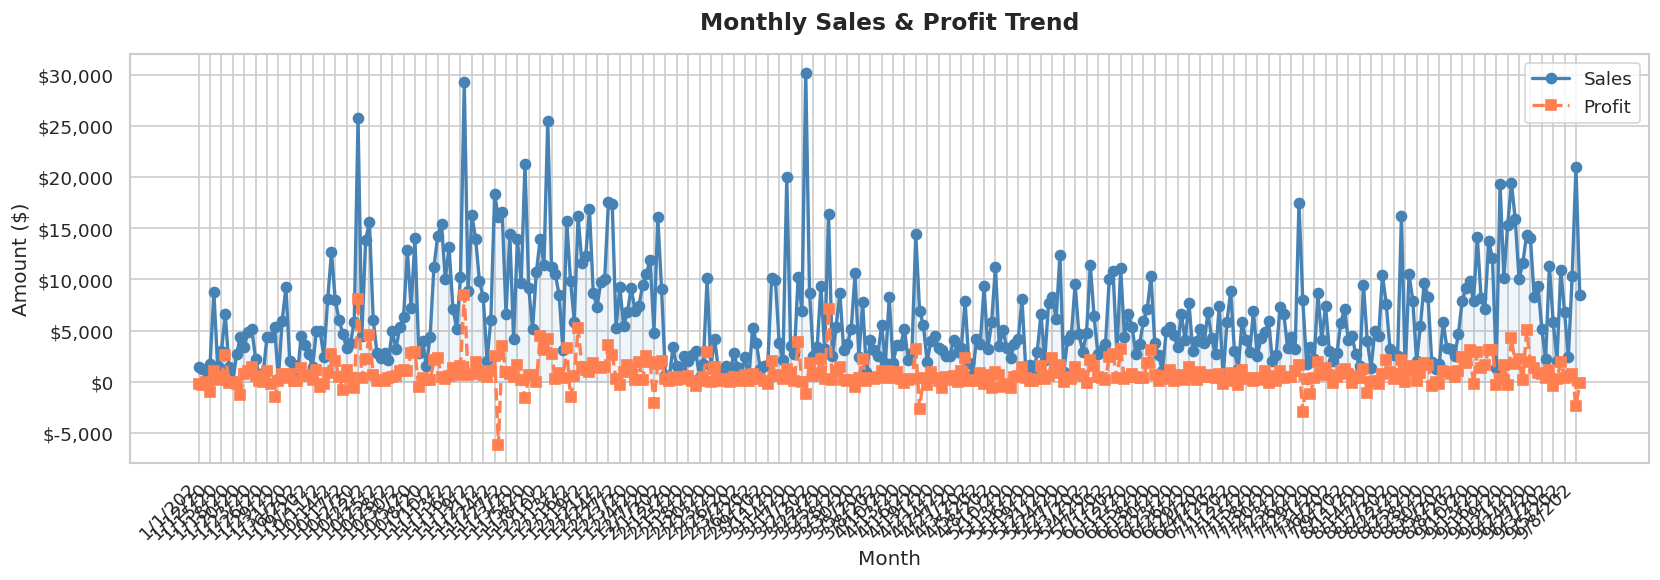

✅ Chart 2 saved!


In [ ]:
# ── Chart 2: Monthly Sales Trend ──
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_monthly['Month'], df_monthly['Monthly_Sales'], marker='o', color='steelblue', linewidth=2, label='Sales')
ax.plot(df_monthly['Month'], df_monthly['Monthly_Profit'], marker='s', color='coral', linewidth=2, linestyle='--', label='Profit')

ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))
ax.set_xticks(range(0, len(df_monthly), 3))
ax.set_xticklabels(df_monthly['Month'].iloc[::3], rotation=45, ha='right')
ax.legend()
ax.fill_between(df_monthly['Month'], df_monthly['Monthly_Sales'], alpha=0.08, color='steelblue')

plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved!')

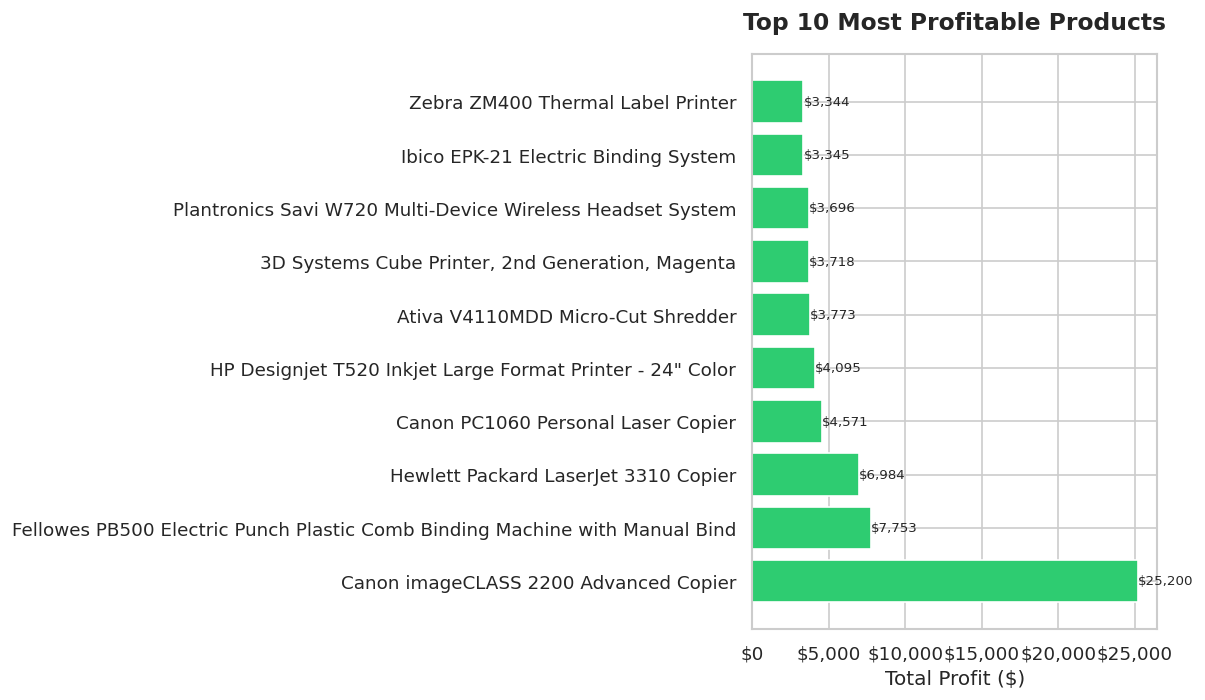

✅ Chart 3 saved!


In [ ]:
# ── Chart 3: Top 10 Products by Profit ──
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_top_products['Total_Profit']]
bars = ax.barh(df_top_products['Product Name'], df_top_products['Total_Profit'], color=colors)

ax.set_title('Top 10 Most Profitable Products', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 10, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart3_top_products.png', bbox_inches='tight')
plt.show()
print('✅ Chart 3 saved!')

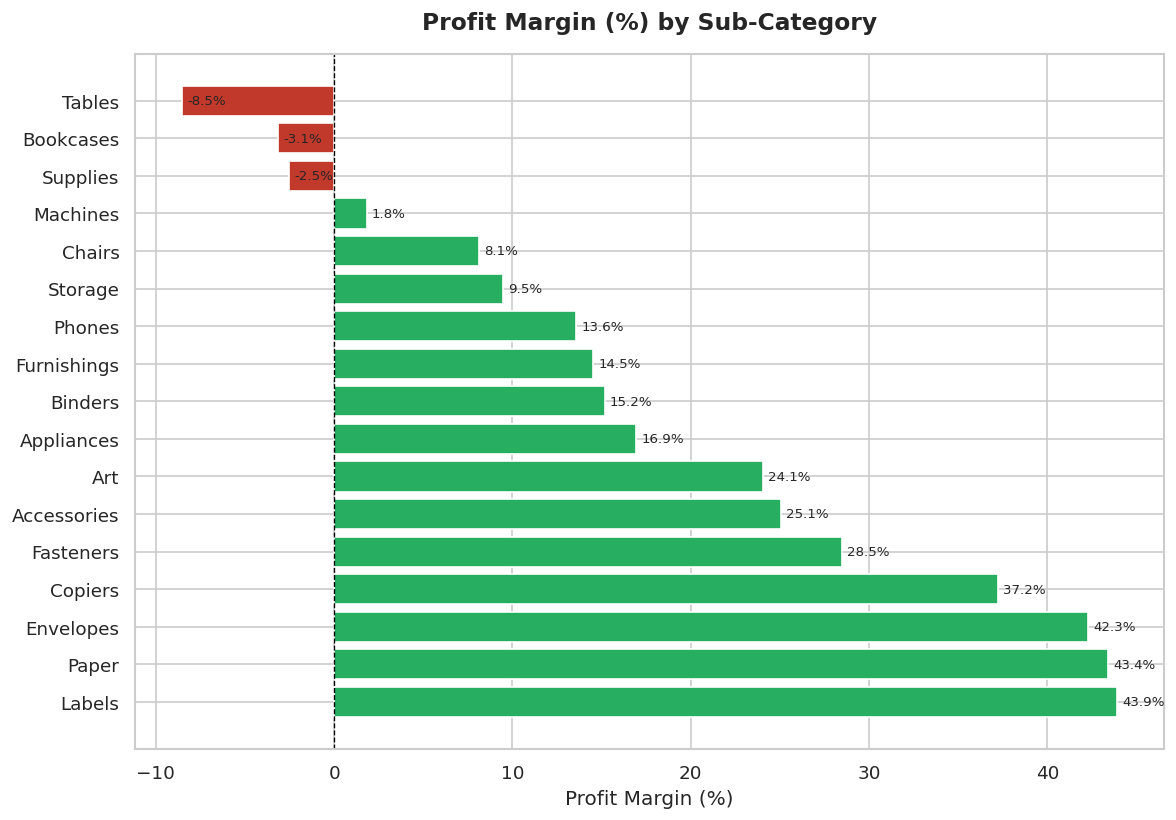

✅ Chart 4 saved!


In [ ]:
# ── Chart 4: Profit Margin by Sub-Category ──
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#27ae60' if x > 0 else '#c0392b' for x in df_subcategory['Profit_Margin_Pct']]
bars = ax.barh(df_subcategory['Sub-Category'], df_subcategory['Profit_Margin_Pct'], color=colors)

ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Profit Margin (%) by Sub-Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Profit Margin (%)')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart4_profit_margin.png', bbox_inches='tight')
plt.show()
print('✅ Chart 4 saved!')

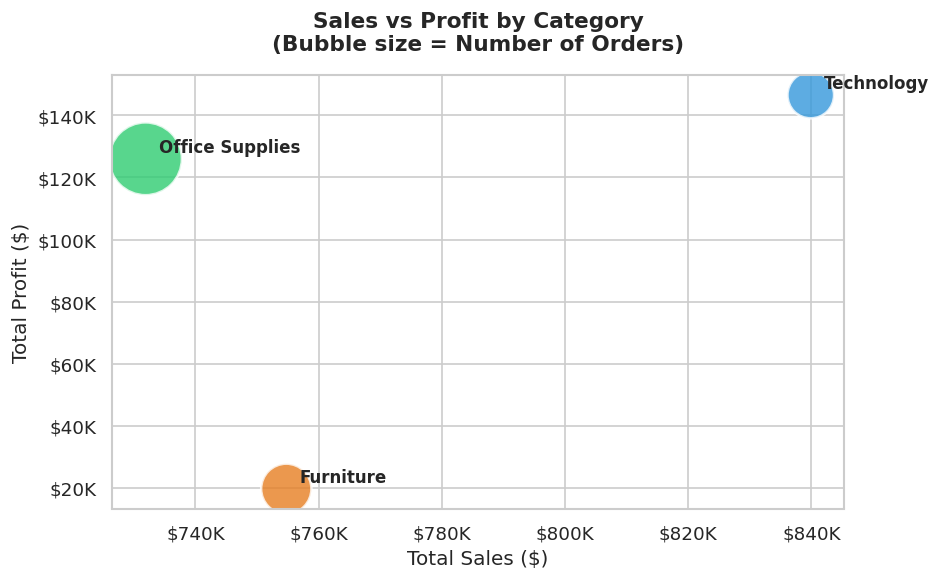

✅ Chart 5 saved!


In [ ]:
# ── Chart 5: Sales vs Profit by Category (Bubble feel) ──
fig, ax = plt.subplots(figsize=(8, 5))

colors_cat = ['#3498db', '#e67e22', '#2ecc71']
scatter = ax.scatter(
    df_category['Total_Sales'],
    df_category['Total_Profit'],
    s=df_category['Total_Orders'] * 0.5,
    c=colors_cat,
    alpha=0.8,
    edgecolors='white',
    linewidths=1.5
)

for i, row in df_category.iterrows():
    ax.annotate(row['Category'],
                (row['Total_Sales'], row['Total_Profit']),
                textcoords='offset points', xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_title('Sales vs Profit by Category\n(Bubble size = Number of Orders)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Total Profit ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'${val/1000:.0f}K'))

plt.tight_layout()
plt.savefig('chart5_category_scatter.png', bbox_inches='tight')
plt.show()
print('✅ Chart 5 saved!')

---
## 💡 Step 7: Key Business Insights
Run this cell to auto-generate a summary of what the data tells us.

In [ ]:
top_region = df_region.iloc[0]
worst_region = df_region.iloc[-1]
best_product = df_top_products.iloc[0]
worst_product = df_bottom_products.iloc[0]
best_category = df_category.iloc[0]
best_margin_subcat = df_subcategory.iloc[0]
worst_margin_subcat = df_subcategory.iloc[-1]

print('=' * 55)
print('         📋 KEY BUSINESS INSIGHTS SUMMARY')
print('=' * 55)
print(f"\n📍 REGIONS")
print(f"   Best region:  {top_region['Region']} — ${top_region['Total_Sales']:,.0f} in sales, ${top_region['Total_Profit']:,.0f} profit")
print(f"   Worst region: {worst_region['Region']} — ${worst_region['Total_Sales']:,.0f} in sales, ${worst_region['Total_Profit']:,.0f} profit")

print(f"\n🏆 PRODUCTS")
print(f"   Most profitable: {best_product['Product Name'][:45]}... (${best_product['Total_Profit']:,.0f})")
print(f"   Biggest loss:    {worst_product['Product Name'][:45]}... (${worst_product['Total_Profit']:,.0f})")

print(f"\n🗂️  CATEGORIES")
print(f"   Top by sales: {best_category['Category']} — ${best_category['Total_Sales']:,.0f}")

print(f"\n📊 PROFIT MARGINS")
print(f"   Best sub-category:  {best_margin_subcat['Sub-Category']} ({best_margin_subcat['Profit_Margin_Pct']}%)")
print(f"   Worst sub-category: {worst_margin_subcat['Sub-Category']} ({worst_margin_subcat['Profit_Margin_Pct']}%)")
print('\n' + '=' * 55)
print('✅ Analysis Complete! Save & share this notebook.')
print('=' * 55)

         📋 KEY BUSINESS INSIGHTS SUMMARY

📍 REGIONS
   Best region:  West — $739,814 in sales, $110,799 profit
   Worst region: South — $391,722 in sales, $46,749 profit

🏆 PRODUCTS
   Most profitable: Canon imageCLASS 2200 Advanced Copier... ($25,200)
   Biggest loss:    Cubify CubeX 3D Printer Double Head Print... ($-8,880)

🗂️  CATEGORIES
   Top by sales: Technology — $839,893

📊 PROFIT MARGINS
   Best sub-category:  Labels (43.9%)
   Worst sub-category: Tables (-8.53%)

✅ Analysis Complete! Save & share this notebook.


---
## 💾 Step 8: Download Your Charts

In [ ]:
from google.colab import files

chart_files = [
    'chart1_region.png',
    'chart2_monthly_trend.png',
    'chart3_top_products.png',
    'chart4_profit_margin.png',
    'chart5_category_scatter.png'
]

for chart in chart_files:
    files.download(chart)

print('✅ All charts downloaded! Use them in your portfolio.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded! Use them in your portfolio.
